# Mann-Whitney-U-Test – einfach erklärt

> Quelle: [numiqo.de](https://numiqo.de/tutorial/mann-whitney-u-test)

Der **Mann-Whitney-U-Test** (Wilcoxon-Rangsummentest) ist das
nichtparametrische Gegenstück zum **unabhängigen t-Test**. Er prüft,
ob zwei unabhängige Gruppen sich in ihrer zentralen Tendenz unterscheiden –
**ohne Normalverteilungsvoraussetzung**.

**Berechnung – U-Werte:**
$$U_1 = n_1 n_2 + \frac{n_1(n_1+1)}{2} - T_1, \qquad U_2 = n_1 n_2 + \frac{n_2(n_2+1)}{2} - T_2$$

$$U = \min(U_1, U_2)$$

**z-Approximation (n > 25):**
$$z = \frac{U - \mu_U}{\sigma_U}, \qquad \mu_U = \frac{n_1 n_2}{2}, \qquad \sigma_U = \sqrt{\frac{n_1 n_2 (n_1+n_2+1)}{12}}$$

**Effektstärke r:**
$$r = \frac{|z|}{\sqrt{n_1 + n_2}}$$

| r | Interpretation |
|---|---|
| < 0,3 | Kleiner Effekt |
| 0,3 – 0,5 | Mittlerer Effekt |
| > 0,5 | Großer Effekt |

**Voraussetzungen:**
- Zwei **unabhängige** Stichproben
- Mindestens **ordinales** Skalenniveau
- Keine Normalverteilung nötig
- Bei abhängigen Stichproben → **Wilcoxon-Test**

**Signifikanz (numiqo-Regel):**
- $n_1 + n_2 < 30$ → exakte Signifikanz
- $n_1 + n_2 \geq 30$ → asymptotische Signifikanz (z-Approximation)

In [7]:
print("Kernel läuft")

Kernel läuft


In [8]:
import matplotlib
matplotlib.use("Agg")
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats
from scipy.stats import mannwhitneyu, rankdata

# matplotlib rendert di ePlots direkt im Notebook ohne plt.show()
%matplotlib inline

np.random.seed(42)
print("Bibliotheken erfolgreich geladen.")

Bibliotheken erfolgreich geladen.


## 1. Das numiqo-Beispiel: Reaktionszeit nach Geschlecht

**Fragestellung:** Gibt es einen Unterschied in der Reaktionszeit
zwischen Frauen und Männern?

**Datensatz (n = 11):**

| Geschlecht | weiblich | weiblich | weiblich | weiblich | weiblich | weiblich | männlich | männlich | männlich | männlich | männlich |
|---|---|---|---|---|---|---|---|---|---|---|---|
| Reaktionszeit | 34 | 36 | 41 | 43 | 44 | 37 | 45 | 33 | 35 | 39 | 42 |

**Erwartete numiqo-Ergebnisse:**
- Median Frauen = 39, Median Männer = 39
- U = 14, p = 0,931 (exakt, zweiseitig) → **nicht signifikant**
- Effektstärke r = 0,06 → kleiner Effekt

In [9]:
# numiqo-Datensatz: Reaktionszeit
frauen   = np.array([34, 36, 41, 43, 44, 37], dtype=float)
maenner  = np.array([45, 33, 35, 39, 42],     dtype=float)
n1, n2   = len(frauen), len(maenner)

print("Deskriptive Statistiken")
print("Gruppe          n   Median     MW     SD")
for name, g in [("Frauen", frauen), ("Männer", maenner)]:
    print(name + "        " + str(len(g)) + "   " +
          str(np.median(g)) + "   " +
          str(round(g.mean(), 2)) + "   " +
          str(round(g.std(ddof=1), 2)))
print()

# Ränge berechnen
alle    = np.concatenate([frauen, maenner])
gruppe  = ["w"]*n1 + ["m"]*n2
raenge  = rankdata(alle)
rang_w  = raenge[:n1]
rang_m  = raenge[n1:]
T1, T2  = rang_w.sum(), rang_m.sum()

print("Ränge")
print("Wert  Gruppe  Rang")
for w, g, r in sorted(zip(alle, gruppe, raenge)):
    print(str(w) + "    " + g + "      " + str(r))
print()
print("Rangsumme T1 (Frauen):  " + str(T1) + "  (numiqo: 37)")
print("Rangsumme T2 (Männer): " + str(T2) + "  (numiqo: 29)")
print()

# U-Werte manuell
U1 = n1*n2 + n1*(n1+1)/2 - T1
U2 = n1*n2 + n2*(n2+1)/2 - T2
U  = min(U1, U2)
print("U1 = " + str(U1) + "  U2 = " + str(U2) + "  U = " + str(U) + "  (numiqo: 14)")
print()

# Exakter Test (kleine Stichprobe n1+n2 < 30)
U_scipy, p_exact = mannwhitneyu(frauen, maenner, alternative="two-sided",
                                method="exact")
print("Mann-Whitney-U-Test (exakt)")
print("U = " + str(U_scipy) + "  p = " + str(round(p_exact, 4)) + "  (numiqo: p=0,931)")
print()

# z-Approximation zur Demonstration
mu_U  = n1*n2 / 2
sig_U = np.sqrt(n1*n2*(n1+n2+1) / 12)
z_val = (U - mu_U) / sig_U
p_approx = 2 * stats.norm.sf(abs(z_val))
r_eff = abs(z_val) / np.sqrt(n1+n2)

print("z-Approximation (Demonstration)")
print("mu_U  = " + str(mu_U))
print("sig_U = " + str(round(sig_U, 4)))
print("z     = " + str(round(z_val, 4)))
print("p     = " + str(round(p_approx, 4)))
print("r     = " + str(round(r_eff, 4)) + " -> kleiner Effekt  (numiqo: r=0,06)")
print()
print("Entscheidung: p=" + str(round(p_exact, 3)) + " > 0.05 -> H0 nicht abgelehnt")
print("Kein signifikanter Unterschied in der Reaktionszeit zwischen Frauen und Maennern.")

Deskriptive Statistiken
Gruppe          n   Median     MW     SD
Frauen        6   39.0   39.17   4.07
Männer        5   39.0   38.8   4.92

Ränge
Wert  Gruppe  Rang
33.0    m      1.0
34.0    w      2.0
35.0    m      3.0
36.0    w      4.0
37.0    w      5.0
39.0    m      6.0
41.0    w      7.0
42.0    m      8.0
43.0    w      9.0
44.0    w      10.0
45.0    m      11.0

Rangsumme T1 (Frauen):  37.0  (numiqo: 37)
Rangsumme T2 (Männer): 29.0  (numiqo: 29)

U1 = 14.0  U2 = 16.0  U = 14.0  (numiqo: 14)

Mann-Whitney-U-Test (exakt)
U = 16.0  p = 0.9307  (numiqo: p=0,931)

z-Approximation (Demonstration)
mu_U  = 15.0
sig_U = 5.4772
z     = -0.1826
p     = 0.8551
r     = 0.055 -> kleiner Effekt  (numiqo: r=0,06)

Entscheidung: p=0.931 > 0.05 -> H0 nicht abgelehnt
Kein signifikanter Unterschied in der Reaktionszeit zwischen Frauen und Maennern.


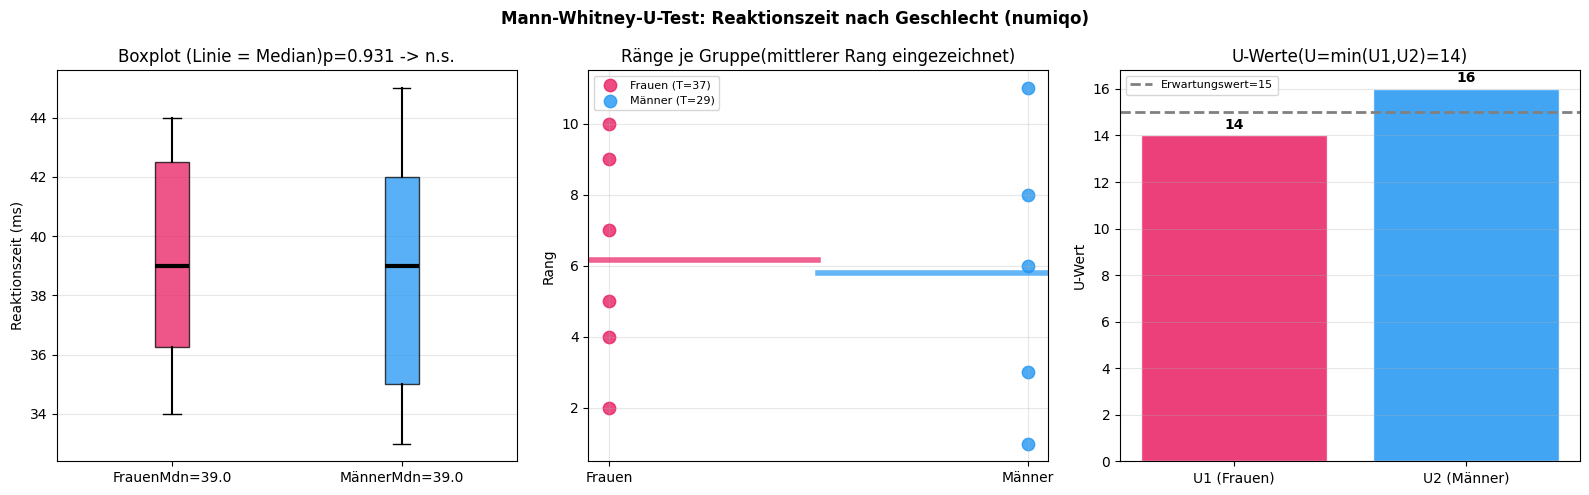

In [14]:
# Visualisierung
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle("Mann-Whitney-U-Test: Reaktionszeit nach Geschlecht (numiqo)",
             fontsize=12, fontweight="bold")

farben = {"Frauen": "#E91E63", "Männer": "#2196F3"}

# 1. Boxplot mit Medianen
bp = axes[0].boxplot([frauen, maenner], patch_artist=True,
                     medianprops=dict(color="black", linewidth=3),
                     whiskerprops=dict(linewidth=1.5))
for patch, fc in zip(bp["boxes"], farben.values()):
    patch.set_facecolor(fc); patch.set_alpha(0.75)
axes[0].set_title("Boxplot (Linie = Median)p=" + str(round(p_exact, 3)) + " -> n.s.")
axes[0].set_ylabel("Reaktionszeit (ms)")
axes[0].set_xticks([1, 2])
axes[0].set_xticklabels(["FrauenMdn=" + str(np.median(frauen)),
                          "MännerMdn=" + str(np.median(maenner))])
axes[0].grid(axis="y", alpha=0.3)

# 2. Rang-Streifen
for idx, (name, g, rang, fc) in enumerate(zip(
    ["Frauen", "Männer"], [frauen, maenner], [rang_w, rang_m], farben.values()
)):
    axes[1].scatter([idx+1]*len(rang), rang, color=fc, s=80, alpha=0.8,
                    label=name + " (T=" + str(int(rang.sum())) + ")")
    axes[1].axhline(rang.mean(), xmin=idx/2, xmax=(idx+1)/2,
                    color=fc, linewidth=4, alpha=0.7)
axes[1].set_title("Ränge je Gruppe(mittlerer Rang eingezeichnet)")
axes[1].set_ylabel("Rang")
axes[1].set_xticks([1, 2])
axes[1].set_xticklabels(["Frauen", "Männer"])
axes[1].legend(fontsize=8)
axes[1].grid(alpha=0.3)

# 3. U-Werte visualisieren
u_labels = ["U1 (Frauen)", "U2 (Männer)"]
u_werte  = [U1, U2]
bars = axes[2].bar(u_labels, u_werte, color=[farben["Frauen"], farben["Männer"]],
                   edgecolor="white", alpha=0.85)
axes[2].axhline(n1*n2/2, color="gray", linestyle="--", linewidth=2,
                label="Erwartungswert=" + str(n1*n2//2))
axes[2].set_title("U-Werte(U=min(U1,U2)=" + str(int(U)) + ")")
axes[2].set_ylabel("U-Wert")
axes[2].legend(fontsize=8)
axes[2].grid(axis="y", alpha=0.3)
for bar, val in zip(bars, u_werte):
    axes[2].text(bar.get_x() + bar.get_width()/2, val + 0.3,
                 str(int(val)), ha="center", fontsize=10, fontweight="bold")

plt.tight_layout()
plt.show()

## 2. Verbundene Ränge (Ties)

Wenn mehrere Beobachtungen denselben Wert haben, teilen sie sich den **mittleren Rang**
(Durchschnitt der betroffenen Rangplätze).

**Beispiel (numiqo):** Reaktionszeit 34 kommt zweimal vor → Ränge 2 und 3 → mittlerer Rang = **2,5**

In [11]:
# Verbundene Ränge demonstrieren
rz_w2 = np.array([34, 36, 39, 43, 44, 37], dtype=float)
rz_m2 = np.array([45, 33, 34, 39, 39, 42], dtype=float)  # 34 + 39 doppelt

alle2   = np.concatenate([rz_w2, rz_m2])
gruppe2 = ["w"]*len(rz_w2) + ["m"]*len(rz_m2)
raenge2 = rankdata(alle2)  # scipy verwendet automatisch mittlere Raenge bei Ties

print("Verbundene Ränge")
print("Wert  Gruppe  Rang   Hinweis")
seen = {}
for w, g, r in sorted(zip(alle2, gruppe2, raenge2)):
    key = str(w)
    hinweis = ""
    if key in seen:
        hinweis = "<- Tie! Mittlerer Rang"
    else:
        seen[key] = r
    print(str(w) + "    " + g + "      " + str(r) + "   " + hinweis)
print()

U_t, p_t = mannwhitneyu(rz_w2, rz_m2, alternative="two-sided")
print("Mann-Whitney-U mit Ties: U=" + str(U_t) + ", p=" + str(round(p_t, 4)))
print("scipy berücksichtigt Ties automatisch.")

Verbundene Ränge
Wert  Gruppe  Rang   Hinweis
33.0    m      1.0   
34.0    m      2.5   
34.0    w      2.5   <- Tie! Mittlerer Rang
36.0    w      4.0   
37.0    w      5.0   
39.0    m      7.0   
39.0    m      7.0   <- Tie! Mittlerer Rang
39.0    w      7.0   <- Tie! Mittlerer Rang
42.0    m      9.0   
43.0    w      10.0   
44.0    w      11.0   
45.0    m      12.0   

Mann-Whitney-U mit Ties: U=18.5, p=1.0
scipy berücksichtigt Ties automatisch.


## 3. Schritt-für-Schritt-Berechnung

1. Alle Werte beider Gruppen gemeinsam ranken (bei Ties: mittlerer Rang)
2. Rangsummen T₁ und T₂ je Gruppe berechnen
3. U-Werte: $U_1 = n_1 n_2 + \frac{n_1(n_1+1)}{2} - T_1$
4. $U = \min(U_1, U_2)$
5. Bei n₁+n₂ < 30: exakter p-Wert aus Tabelle
6. Bei n₁+n₂ ≥ 30: z-Approximation → p aus Normalverteilung
7. Effektstärke: $r = |z| / \sqrt{n_1+n_2}$

In [12]:
# Schritt-für-Schritt: numiqo-Hauptbeispiel
print("Schritt-für-Schritt: Reaktionszeit-Beispiel")
print()
print("Schritt 1 - Daten:")
print("Frauen:  " + str(frauen.tolist()))
print("Männer: " + str(maenner.tolist()))
print()
print("Schritt 2 - Gemeinsame Rangvergabe:")
for w, g, r in sorted(zip(alle, gruppe, raenge)):
    print("  " + str(w) + " (" + g + ") -> Rang " + str(r))
print()
print("Schritt 3 - Rangsummen:")
print("  T1 (Frauen):  " + str(int(T1)))
print("  T2 (Männer): " + str(int(T2)))
print()
print("Schritt 4 - U-Werte:")
print("  U1 = " + str(n1) + "*" + str(n2) + " + " + str(n1) + "*" +
      str(n1+1) + "/2 - " + str(int(T1)) + " = " + str(int(U1)))
print("  U2 = " + str(n1) + "*" + str(n2) + " + " + str(n2) + "*" +
      str(n2+1) + "/2 - " + str(int(T2)) + " = " + str(int(U2)))
print("  U = min(" + str(int(U1)) + ", " + str(int(U2)) + ") = " + str(int(U)))
print()
print("Schritt 5 - n1+n2=" + str(n1+n2) + " < 30 -> exakter p-Wert")
print("  p (exakt, zweiseitig) = " + str(round(p_exact, 4)))
print()
print("Schritt 6 - Effektstärke:")
print("  z = " + str(round(z_val, 4)))
print("  r = |z| / sqrt(n1+n2) = " + str(round(abs(z_val), 4)) +
      " / " + str(np.sqrt(n1+n2).round(4)) + " = " + str(round(r_eff, 4)))
interp_r = "klein" if r_eff < 0.3 else ("mittel" if r_eff < 0.5 else "gross")
print("  -> " + interp_r + " Effekt")

Schritt-für-Schritt: Reaktionszeit-Beispiel

Schritt 1 - Daten:
Frauen:  [34.0, 36.0, 41.0, 43.0, 44.0, 37.0]
Männer: [45.0, 33.0, 35.0, 39.0, 42.0]

Schritt 2 - Gemeinsame Rangvergabe:
  33.0 (m) -> Rang 1.0
  34.0 (w) -> Rang 2.0
  35.0 (m) -> Rang 3.0
  36.0 (w) -> Rang 4.0
  37.0 (w) -> Rang 5.0
  39.0 (m) -> Rang 6.0
  41.0 (w) -> Rang 7.0
  42.0 (m) -> Rang 8.0
  43.0 (w) -> Rang 9.0
  44.0 (w) -> Rang 10.0
  45.0 (m) -> Rang 11.0

Schritt 3 - Rangsummen:
  T1 (Frauen):  37
  T2 (Männer): 29

Schritt 4 - U-Werte:
  U1 = 6*5 + 6*7/2 - 37 = 14
  U2 = 6*5 + 5*6/2 - 29 = 16
  U = min(14, 16) = 14

Schritt 5 - n1+n2=11 < 30 -> exakter p-Wert
  p (exakt, zweiseitig) = 0.9307

Schritt 6 - Effektstärke:
  z = -0.1826
  r = |z| / sqrt(n1+n2) = 0.1826 / 3.3166 = 0.055
  -> klein Effekt


In [15]:
# APA-Ausgabe-Funktion
def mann_whitney_apa(g1, g2, name1="Gruppe 1", name2="Gruppe 2",
                     abh_var="Variable", alpha=0.05):
    g1, g2 = np.asarray(g1, dtype=float), np.asarray(g2, dtype=float)
    n1_f, n2_f = len(g1), len(g2)
    methode = "exact" if n1_f + n2_f < 30 else "asymptotic"
    U_f, p_f = mannwhitneyu(g1, g2, alternative="two-sided", method=methode)

    # z-Wert fuer Effektstärke
    mu_f  = n1_f * n2_f / 2
    sig_f = np.sqrt(n1_f * n2_f * (n1_f + n2_f + 1) / 12)
    z_f   = (U_f - mu_f) / sig_f
    r_f   = abs(z_f) / np.sqrt(n1_f + n2_f)
    interp = "klein" if r_f < 0.3 else ("mittel" if r_f < 0.5 else "gross")

    sig_txt = "signifikant" if p_f < alpha else "NICHT signifikant"
    p_str = "p < .001" if p_f < 0.001 else "p = " + str(round(p_f, 3)).replace("0.", ".")

    print("Mann-Whitney-U-Test: " + abh_var)
    print("Methode: " + methode + " (n=" + str(n1_f+n2_f) + ")")
    print()
    print(name1 + ": Mdn=" + str(np.median(g1)) + ", n=" + str(n1_f))
    print(name2 + ": Mdn=" + str(np.median(g2)) + ", n=" + str(n2_f))
    print()
    print("U=" + str(int(U_f)) + ", " + p_str + ", r=" + str(round(r_f, 3)) +
          " (" + interp + " Effekt)")
    print("Ergebnis: " + sig_txt)
    print()

# numiqo-Hauptbeispiel
mann_whitney_apa(frauen, maenner, "Frauen", "Männer", "Reaktionszeit (ms)")
print()

# Signifikantes Beispiel
np.random.seed(7)
g_sig1 = np.random.exponential(3, 30) + 5
g_sig2 = np.random.exponential(3, 30) + 10
mann_whitney_apa(g_sig1, g_sig2, "Gruppe A", "Gruppe B", "Messwert")

Mann-Whitney-U-Test: Reaktionszeit (ms)
Methode: exact (n=11)

Frauen: Mdn=39.0, n=6
Männer: Mdn=39.0, n=5

U=16, p = .931, r=0.055 (klein Effekt)
Ergebnis: NICHT signifikant


Mann-Whitney-U-Test: Messwert
Methode: asymptotic (n=60)

Gruppe A: Mdn=7.1547421008417835, n=30
Gruppe B: Mdn=11.826290878411138, n=30

U=113, p < .001, r=0.643 (gross Effekt)
Ergebnis: signifikant



## 4. Zusammenfassung

```
Mann-Whitney-U-Test – Übersicht
│
├── WANN?
│   Nichtparametrisches Gegenstück zum unabh. t-Test
│   Zwei unabhängige Gruppen, kein NV nötig
│   Mindestens ordinales Skalenniveau
│
├── HYPOTHESEN
│   H0: Keine Unterschied in der zentralen Tendenz
│   H1: Unterschied in der zentralen Tendenz
│
├── BERECHNUNG
│   1. Alle Werte gemeinsam ranken (Ties: mittlerer Rang)
│   2. Rangsummen T1, T2 je Gruppe
│   3. U1 = n1*n2 + n1*(n1+1)/2 - T1
│      U2 = n1*n2 + n2*(n2+1)/2 - T2
│      U  = min(U1, U2)
│   4. p-Wert:
│      n1+n2 < 30  -> exakt
│      n1+n2 >= 30 -> z-Approximation
│   5. Effektstärke r = |z| / sqrt(n1+n2)
│
├── EFFEKTSTÄRKE r
│   < 0.3: klein | 0.3-0.5: mittel | > 0.5: gross
│
├── numiqo-BEISPIEL: Reaktionszeit (Frauen vs. Männer)
│   U=14, p=0.931 (exakt) -> n.s.
│   Mdn(Frauen)=39, Mdn(Männer)=39
│   r=0.06 -> kleiner Effekt
│
└── PYTHON
    from scipy.stats import mannwhitneyu
    U, p = mannwhitneyu(g1, g2, alternative="two-sided",
                        method="exact")  # oder "asymptotic"
```

---
Quelle: [numiqo.de/tutorial/mann-whitney-u-test](https://numiqo.de/tutorial/mann-whitney-u-test)